In [1]:
import pandas as pd
df = pd.read_csv("../data/fraud_data.csv")
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [2]:
print("Shape:", df.shape)
print("\nColumns:",df.columns.tolist())

Shape: (10000, 10)

Columns: ['transaction_id', 'amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'is_fraud']


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [4]:
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [5]:
df["is_fraud"].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

In [6]:
df["is_fraud"].value_counts(normalize=True) * 100

is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64

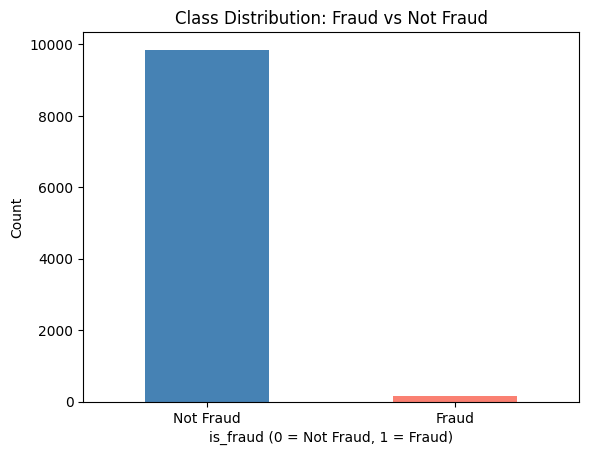

In [7]:
import matplotlib.pyplot as plt

df["is_fraud"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Class Distribution: Fraud vs Not Fraud")
plt.xlabel("is_fraud (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.xticks([0, 1], ["Not Fraud", "Fraud"], rotation=0)
plt.show()

In [8]:
# Compare average values for fraud vs not fraud
df.groupby("is_fraud")[["amount", "transaction_hour", "foreign_transaction", "location_mismatch", "device_trust_score", "velocity_last_24h", "cardholder_age"]].mean()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
is_fraud,,,,,,,
0,175.333015,11.712154,0.090974,0.079704,62.165804,1.990557,43.469794
1,216.182980,3.841060,0.543046,0.476821,37.867550,3.205298,43.397351


C:\Users\shaky\AppData\Local\Temp\ipykernel_7728\542781570.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="is_fraud", y="device_trust_score", data=df, palette=["steelblue", "salmon"], ax=axes[0])
C:\Users\shaky\AppData\Local\Temp\ipykernel_7728\542781570.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Not Fraud", "Fraud"])
C:\Users\shaky\AppData\Local\Temp\ipykernel_7728\542781570.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="is_fraud", y="transaction_hour", data=df, palette=["steelblue", "salmon"], ax=axes[1])
C:\Users\shaky\AppData\Local\Temp\ipykernel_7728\5

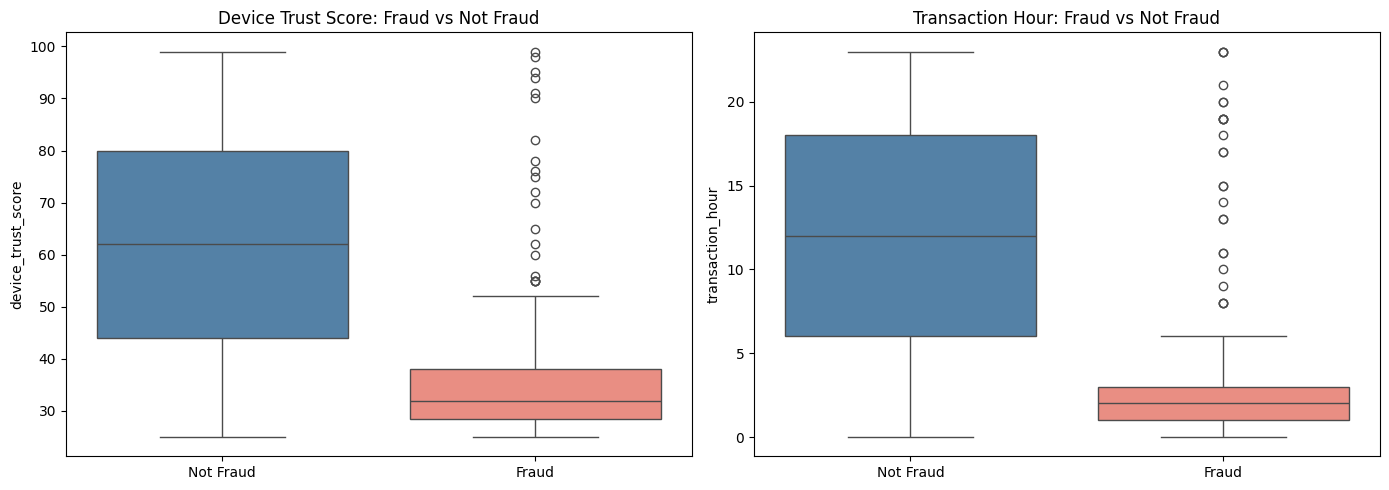

In [9]:
import seaborn as sns 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Device Trust Score Distribution ----
sns.boxplot(x="is_fraud", y="device_trust_score", data=df, palette=["steelblue", "salmon"], ax=axes[0])
axes[0].set_title("Device Trust Score: Fraud vs Not Fraud")
axes[0].set_xticklabels(["Not Fraud", "Fraud"])
axes[0].set_xlabel("")

# ---- Transaction Hour Distribution ---
sns.boxplot(x="is_fraud", y="transaction_hour", data=df, palette=["steelblue", "salmon"], ax=axes[1])
axes[1].set_title("Transaction Hour: Fraud vs Not Fraud")
axes[1].set_xticklabels(["Not Fraud", "Fraud"])
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

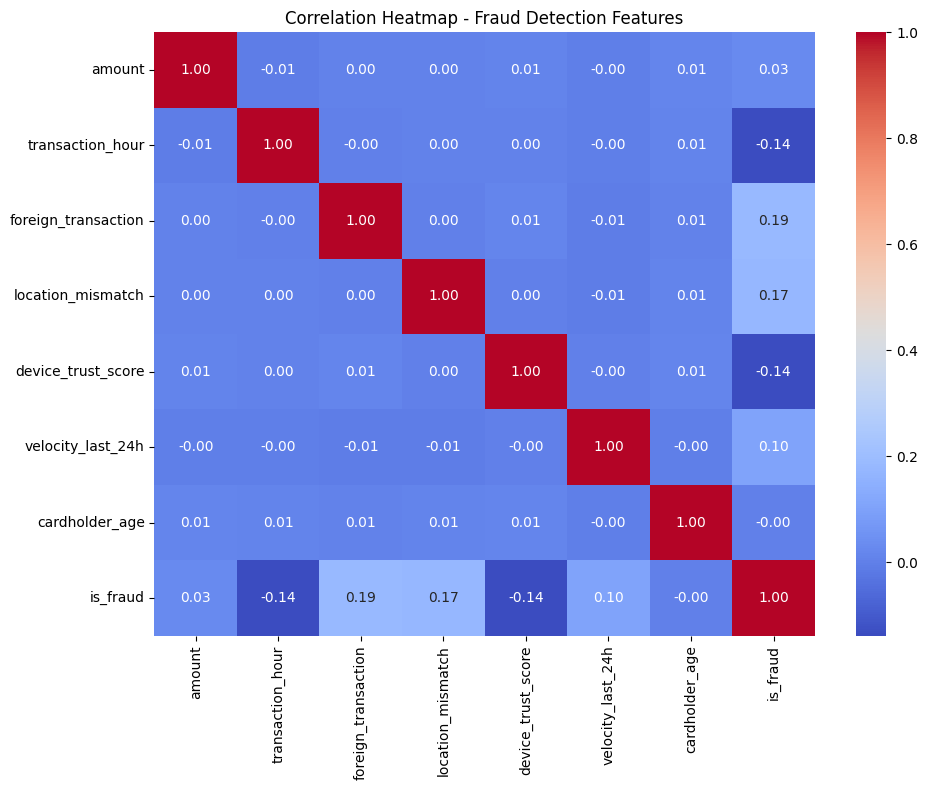

In [10]:
# Select only numerical columns 
# (drop transaction_id - just an identifier, and merchant_category - text column)
numerical_df = df.drop(columns=["transaction_id", "merchant_category"])
 
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Fraud Detection Features")
plt.tight_layout()
plt.show()